In [1]:
from scipy.io import loadmat
import os
from contact_mapper import ContactMapper
from protein_representation import ProteinCollection
from data_scaler import BayesScaler
from gp_regression import GPRegression

from utility import parse_matlab_mutation_file, parse_mutations, convert_graph_from_matlab_file
from utility import convert_aa_sequence, preprocess_observations

import numpy as np
import pickle

In [2]:
!dir .\pdb

 Volume in drive C is Windows
 Volume Serial Number is A079-5C77

 Directory of C:\pro_tooling\pdb

16/01/2021  10.36    <DIR>          .
16/01/2021  10.36    <DIR>          ..
16/01/2021  10.36           264.789 1bni.pdb
16/01/2021  10.28            82.215 1bpi.pdb
16/01/2021  10.26           167.832 1bvc.pdb
16/01/2021  10.26            70.794 1csp.pdb
16/01/2021  10.25           262.764 1lzi.pdb
12/01/2021  17.16            58.968 1pga.pdb
16/01/2021  10.27           164.025 1pin.pdb
16/01/2021  10.27           557.604 1rgg.pdb
16/01/2021  10.27           244.701 1rn1.pdb
16/01/2021  10.27           134.298 1rtb.pdb
16/01/2021  10.36            96.876 1vqb.pdb
16/01/2021  10.25            79.137 2ci2.pdb
16/01/2021  10.25           149.607 2lzm.pdb
16/01/2021  10.26           149.688 2rn2.pdb
16/01/2021  10.27           133.812 4lyz.pdb
              15 File(s)      2.617.110 bytes
               2 Dir(s)  47.190.745.088 bytes free


In [3]:
pdbs = ["2LZM", "1LZI", "2CI2", "1PGA", "2RN2",
        "1CSP", "1BVC", "4LYZ", "1RTB", "1PIN", "1RN1", "1RGG", "1BPI"]
buggy = ["1BNI", "1VQB"]

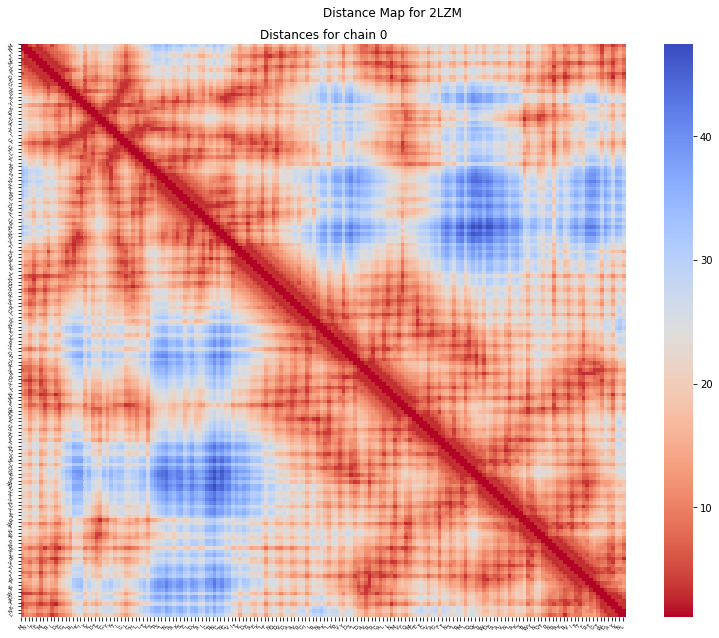

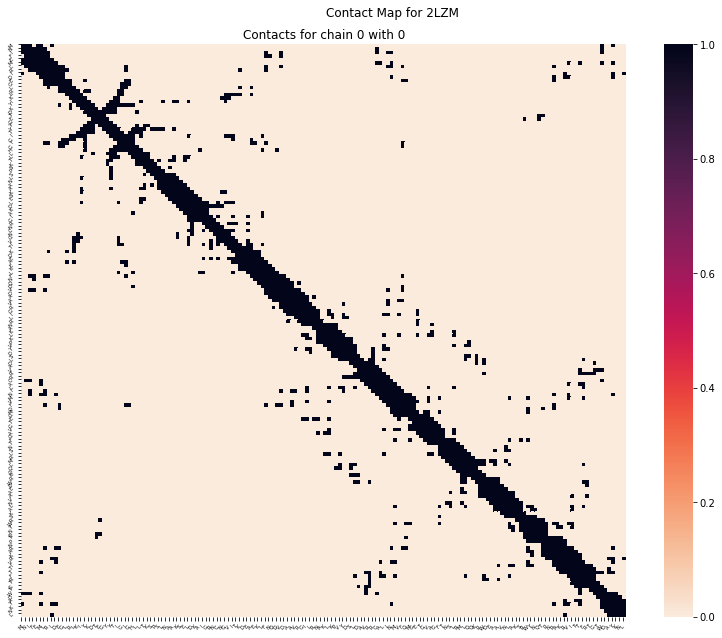

Warmup:   0%|                                                                                  | 0/10500 [00:00, ?it/s]C:\Users\rmich\anaconda3\envs\mgp\lib\site-packages\torch\autograd\__init__.py:202: UserWarning: CUDA initialization: Found no NVIDIA driver on your system. Please check that you have an NVIDIA GPU and installed a driver from http://www.nvidia.com/Download/index.aspx (Triggered internally at  ..\c10\cuda\CUDAFunctions.cpp:100.)
  return Variable._execution_engine.run_backward(
C:\Users\rmich\anaconda3\envs\mgp\lib\site-packages\pyro\poutine\subsample_messenger.py:58: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  result = torch.tensor(0., device=self.device)
Sample: 100%|█████████████████████████████████████| 10500/

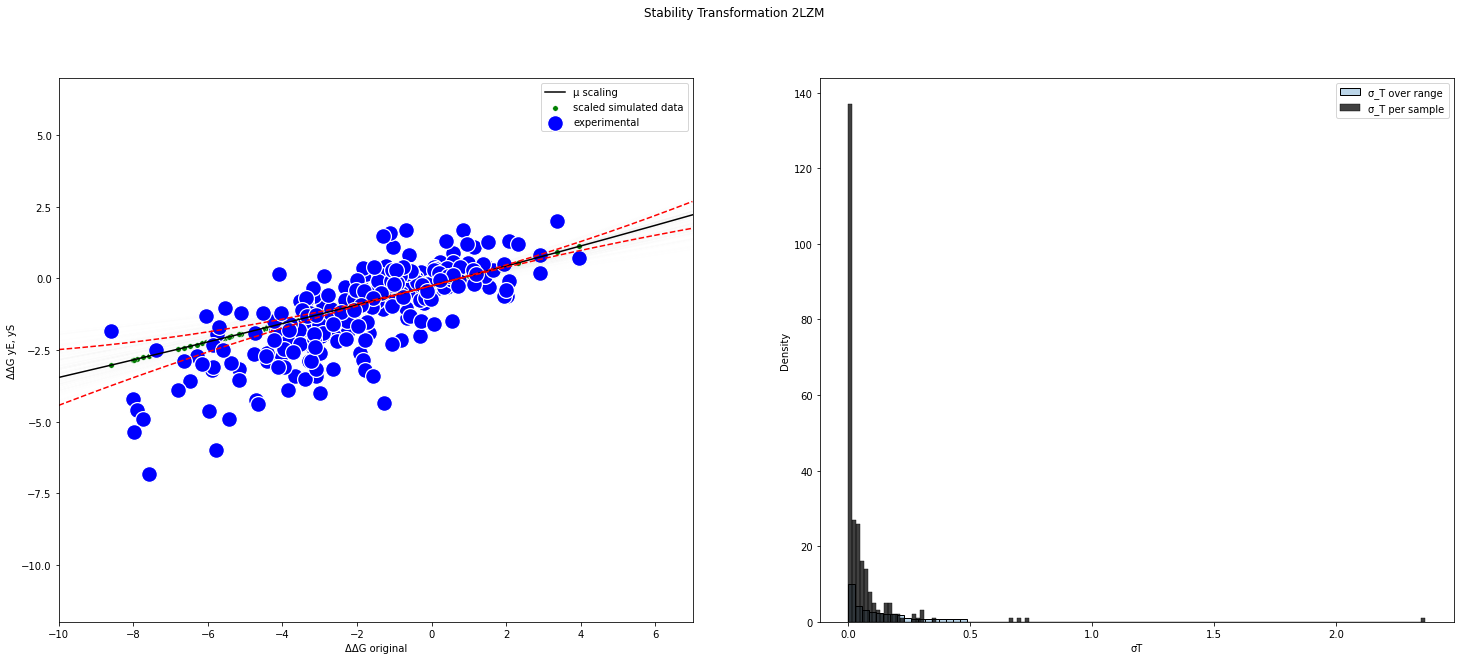

0it [00:00, ?it/s]
0it [00:00, ?it/s]
Matrix: BENS940102: : 0it [00:00, ?it/s]
Matrix: BENS940102: : 1it [00:00,  1.02it/s]
Matrix: BENS940102: : 1it [00:00,  1.02it/s]
Matrix: BENS940102: : 2it [00:01,  1.04it/s]
Matrix: BENS940102: : 2it [00:01,  1.04it/s]
Matrix: BENS940102: : 3it [00:03,  1.21s/it]
Matrix: BENS940102: : 3it [00:03,  1.21s/it]
Matrix: BENS940102: : 4it [00:04,  1.14s/it]
Matrix: BENS940102: : 4it [00:04,  1.14s/it]
Matrix: BENS940102: : 5it [00:05,  1.07s/it]
Matrix: BENS940102: : 5it [00:05,  1.07s/it]
Matrix: BENS940102: : 6it [00:07,  1.30s/it]
Matrix: BENS940102: : 6it [00:07,  1.30s/it]
Matrix: BENS940102: : 7it [00:09,  1.55s/it]
Matrix: BENS940102: : 7it [00:09,  1.55s/it]
Matrix: BENS940102: : 8it [00:10,  1.51s/it]
Matrix: BENS940102: : 8it [00:10,  1.51s/it]
Matrix: BENS940102: : 9it [00:11,  1.43s/it]
Matrix: BENS940102: : 9it [00:11,  1.43s/it]
Matrix: BENS940102: : 10it [00:13,  1.37s/it]
Matrix: BENS940102: : 10it [00:13,  1.37s/it]
Matrix: BENS940102:

Matrix: BENS940102: : 83it [01:38,  1.04s/it]
Matrix: BENS940102: : 84it [01:40,  1.22s/it]
Matrix: BENS940102: : 84it [01:40,  1.22s/it]
Matrix: BENS940102: : 85it [01:41,  1.22s/it]
Matrix: BENS940102: : 85it [01:41,  1.22s/it]
Matrix: BENS940102: : 86it [01:42,  1.20s/it]
Matrix: BENS940102: : 86it [01:42,  1.20s/it]
Matrix: BENS940102: : 87it [01:44,  1.27s/it]
Matrix: BENS940102: : 87it [01:44,  1.27s/it]
Matrix: BENS940102: : 88it [01:45,  1.32s/it]
Matrix: BENS940102: : 88it [01:45,  1.32s/it]
Matrix: BENS940102: : 89it [01:46,  1.20s/it]
Matrix: BENS940102: : 89it [01:46,  1.20s/it]
Matrix: BENS940102: : 90it [01:47,  1.21s/it]
Matrix: BENS940102: : 90it [01:47,  1.21s/it]
Matrix: BENS940102: : 91it [01:49,  1.30s/it]
Matrix: BENS940102: : 91it [01:49,  1.30s/it]
Matrix: BENS940102: : 92it [01:50,  1.22s/it]
Matrix: BENS940102: : 92it [01:50,  1.22s/it]
Matrix: BENS940102: : 93it [01:51,  1.08s/it]
Matrix: BENS940102: : 93it [01:51,  1.08s/it]
Matrix: BENS940102: : 94it [01:52,

Matrix: CSEM940101: : 1it [00:00,  1.11it/s]
Matrix: CSEM940101: : 1it [00:00,  1.11it/s]
Matrix: CSEM940101: : 2it [00:01,  1.09it/s]
Matrix: CSEM940101: : 2it [00:01,  1.09it/s]
Matrix: CSEM940101: : 3it [00:03,  1.16s/it]
Matrix: CSEM940101: : 3it [00:03,  1.16s/it]
Matrix: CSEM940101: : 4it [00:04,  1.14s/it]
Matrix: CSEM940101: : 4it [00:04,  1.14s/it]
Matrix: CSEM940101: : 5it [00:05,  1.07s/it]
Matrix: CSEM940101: : 5it [00:05,  1.07s/it]
Matrix: CSEM940101: : 6it [00:07,  1.29s/it]
Matrix: CSEM940101: : 6it [00:07,  1.29s/it]
Matrix: CSEM940101: : 7it [00:08,  1.49s/it]
Matrix: CSEM940101: : 7it [00:08,  1.49s/it]
Matrix: CSEM940101: : 8it [00:10,  1.47s/it]
Matrix: CSEM940101: : 8it [00:10,  1.47s/it]
Matrix: CSEM940101: : 9it [00:11,  1.40s/it]
Matrix: CSEM940101: : 9it [00:11,  1.40s/it]
Matrix: CSEM940101: : 10it [00:12,  1.34s/it]
Matrix: CSEM940101: : 10it [00:12,  1.34s/it]
Matrix: CSEM940101: : 11it [00:14,  1.43s/it]
Matrix: CSEM940101: : 11it [00:14,  1.43s/it]
Matrix

Matrix: CSEM940101: : 84it [01:39,  1.22s/it]
Matrix: CSEM940101: : 85it [01:41,  1.23s/it]
Matrix: CSEM940101: : 85it [01:41,  1.23s/it]
Matrix: CSEM940101: : 86it [01:42,  1.20s/it]
Matrix: CSEM940101: : 86it [01:42,  1.20s/it]
Matrix: CSEM940101: : 87it [01:43,  1.26s/it]
Matrix: CSEM940101: : 87it [01:43,  1.26s/it]
Matrix: CSEM940101: : 88it [01:45,  1.32s/it]
Matrix: CSEM940101: : 88it [01:45,  1.32s/it]
Matrix: CSEM940101: : 89it [01:46,  1.20s/it]
Matrix: CSEM940101: : 89it [01:46,  1.20s/it]
Matrix: CSEM940101: : 90it [01:47,  1.21s/it]
Matrix: CSEM940101: : 90it [01:47,  1.21s/it]
Matrix: CSEM940101: : 91it [01:48,  1.33s/it]
Matrix: CSEM940101: : 91it [01:48,  1.33s/it]
Matrix: CSEM940101: : 92it [01:49,  1.24s/it]
Matrix: CSEM940101: : 92it [01:49,  1.24s/it]
Matrix: CSEM940101: : 93it [01:50,  1.09s/it]
Matrix: CSEM940101: : 93it [01:50,  1.09s/it]
Matrix: CSEM940101: : 94it [01:51,  1.10s/it]
Matrix: CSEM940101: : 94it [01:51,  1.10s/it]
Matrix: CSEM940101: : 95it [01:53,

Matrix: GONG920101: : 2it [00:01,  1.08it/s]
Matrix: GONG920101: : 2it [00:01,  1.08it/s]
Matrix: GONG920101: : 3it [00:03,  1.15s/it]
Matrix: GONG920101: : 3it [00:03,  1.15s/it]
Matrix: GONG920101: : 4it [00:04,  1.13s/it]
Matrix: GONG920101: : 4it [00:04,  1.13s/it]
Matrix: GONG920101: : 5it [00:05,  1.07s/it]
Matrix: GONG920101: : 5it [00:05,  1.07s/it]
Matrix: GONG920101: : 6it [00:07,  1.29s/it]
Matrix: GONG920101: : 6it [00:07,  1.29s/it]
Matrix: GONG920101: : 7it [00:08,  1.47s/it]
Matrix: GONG920101: : 7it [00:08,  1.47s/it]
Matrix: GONG920101: : 8it [00:10,  1.48s/it]
Matrix: GONG920101: : 8it [00:10,  1.48s/it]
Matrix: GONG920101: : 9it [00:11,  1.40s/it]
Matrix: GONG920101: : 9it [00:11,  1.40s/it]
Matrix: GONG920101: : 10it [00:12,  1.35s/it]
Matrix: GONG920101: : 10it [00:12,  1.35s/it]
Matrix: GONG920101: : 11it [00:14,  1.40s/it]
Matrix: GONG920101: : 11it [00:14,  1.40s/it]
Matrix: GONG920101: : 12it [00:15,  1.32s/it]
Matrix: GONG920101: : 12it [00:15,  1.32s/it]
Matr

...


L-BFGS: 1:   7%|████▋                                                                  | 1/15 [01:53<26:31, 113.66s/it]


Optimization broke.


 26%|███████████████████▉                                                          | 42/164 [59:26<3:55:58, 116.05s/it]

reset parameters ...



L-BFGS: 1:   7%|████▊                                                                   | 1/15 [01:21<19:05, 81.85s/it]

In [ ]:
# get mutations for pdb
exp_mutations = parse_matlab_mutation_file("./data/ddg_protherm.mat", query="ddg_protherm")
sim_mutations = parse_matlab_mutation_file("./data/ddg_rosetta_single.mat", query="ddg_rosetta_single")

results = {}

for pdb in pdbs:
    # load data from reference files
    filename = f"./pdb/{pdb.lower()}.pdb"
    save_fig = os.path.join(os.path.abspath(''), "fig/")
    ref_file = loadmat(f"./data/{pdb.upper()}.mat")
    ref_adj = convert_graph_from_matlab_file(ref_file["contact_map"])
    
    # generate contactmaps, distance matrix plots
    cm1 = ContactMapper(pdb_file=filename, tri_dist=True)
    cm1.plot_distance_matrix(save_fig=save_fig)
    cm1.plot_contact_map(save_fig=save_fig)
    
    # generate sub_matrices and representations ...
    pcol = ProteinCollection(cm1, pdb_ID=pdb, mutations_exp=exp_mutations, mutations_sim=sim_mutations, TESTING=False)
    # pcol.plot_sub_matrices(savefig=save_fig)
   
    # extract mutations
    mut_S_exp, _, ΔΔg_exp, mut_ids_exp = parse_mutations(mutation_dict=exp_mutations.get(pcol.pdb_ID), 
                                                    sequence=pcol.sequence, adjacency=ref_adj)
    mut_S_is, _, ΔΔg_is, mut_ids_is = parse_mutations(mutation_dict=sim_mutations.get(pcol.pdb_ID), 
                                                    sequence=pcol.sequence, adjacency=ref_adj)
    X_exp, X_is = convert_aa_sequence(mut_S_exp), convert_aa_sequence(mut_S_is)
    y_wt = np.array([0])[:, np.newaxis]
    X_wt = convert_aa_sequence([pcol.sequence])
    
    # Bayesian Scaling
    bs = BayesScaler(is_mutations=mut_ids_is, ΔΔg=pcol.ΔΔg_is, exp_mutations=mut_ids_exp, 
                        experimentally_observed_ΔΔg=pcol.ΔΔg_exp, TESTING=False, pdb_ID=pdb.upper())
    ΔΔg_exp = ΔΔg_exp[:, np.newaxis]
    ΔΔg_is_scaled = bs.transform(ΔΔg_is)[:, np.newaxis]
    bs.plot_scaling(save_fig=save_fig)
    
    # Scale y-values as done in the implementation by normalizing with mean and max
    mean_y, max_y, y_wt, ΔΔg_exp, ΔΔg_is_scaled = preprocess_observations(y_wt, ΔΔg_exp, ΔΔg_is_scaled)

    gpr = GPRegression(protein_representation=pcol, X_wt=X_wt, X_exp=X_exp, X_is=X_is, 
                         y_wt=y_wt, y_exp=ΔΔg_exp, y_is=ΔΔg_is_scaled, adjacencies=ref_adj, 
                         σ_T=bs.σ_T, y_max=max_y, y_mean=mean_y)
    opt_results, gpr_results, n_mutations = gpr.position_level_CV()
    results_dict = {"optimization": opt_results, "regression": gpr_results, "mutations": n_mutations}
    results[pdb] = results_dict
    with open(f"./results_{pdb}.pickle", "wb") as outfile:
        pickle.dump(results_dict, outfile)
    
    

In [ ]:
print(results)


In [ ]:
# TODO compute Kernel matrices for each from mutations

In [ ]:
# TODO perform Regression for each

In [ ]:
# TODO scaling + regression

In [ ]:
# TODO compute correlation rho and rmse calculation